In [11]:
import os
import torch
import numpy as np

import pandas as pd
import torch.nn as nn
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
class EMGExtractor:
    """
    Extracts ONLY Deltoid EMG (DELT1, DELT2, DELT3) from AnalogData.mat
    and merges all CSVs into one combined dataset.
    """

    def __init__(
        self,
        base_dir,
        output_dir="EXTRACTED_DELT",
        merged_output="ALL_DELT_RAW.csv",
        remove_zero_rows=True,
    ):
        """
        Parameters:
        -----------
        base_dir : str
            Directory containing subfolders with AnalogData.mat.

        output_dir : str
            Folder where each DELT CSV file is stored.

        merged_output : str
            Path of the final merged dataset.

        remove_zero_rows : bool
            If True, delete zero-only EMG rows.
        """

        self.base_dir = base_dir
        self.output_dir = output_dir
        self.merged_output = merged_output
        self.remove_zero_rows_flag = remove_zero_rows

        # Create output directory
        os.makedirs(self.output_dir, exist_ok=True)

        # Deltoid channel indices
        # EMG7→DELT1, EMG8→DELT2, EMG9→DELT3
        self.deltoid_indices = [6, 7, 8]
        self.deltoid_labels = ["DELT1", "DELT2", "DELT3"]

    # ---------------- Load MATLAB Struct ---------------- #

    def _load_analog_struct(self, mat_path):
        """Safely load AnalogData struct from .mat file."""
        data = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
        return data.get("AnalogData", None)

    # ---------------- Extract Deltoid EMG ---------------- #

    def _extract_deltoid(self, analog):
        """Extract DELT1–DELT3 channels from RawData."""
        rate = int(np.squeeze(analog.Rate))
        raw = np.squeeze(analog.RawData)

        if raw.ndim != 2:
            raise ValueError("RawData is not a valid 2D matrix.")

        return raw[:, self.deltoid_indices], self.deltoid_labels, rate

    # ---------------- Remove Zero Rows ---------------- #

    def _remove_zero_rows(self, emg):
        """Remove rows that contain only zeros (optional)."""
        if not self.remove_zero_rows_flag:
            return emg
        return emg[~np.all(emg == 0, axis=1)]

    # ---------------- Save Individual CSV ---------------- #

    def _save_csv(self, emg, labels, trial_name):
        """Save EMG channels of one trial into CSV."""
        out_name = f"{trial_name}_DELT.csv"
        out_path = os.path.join(self.output_dir, out_name)

        df = pd.DataFrame(emg, columns=labels)
        df.to_csv(out_path, index=False)

        print(f"[✓] Saved {out_name} ({emg.shape[0]} rows)")

    # ---------------- Process Each File ---------------- #

    def _process_single_file(self, mat_path):
        """Extract deltoid EMG from one AnalogData.mat file."""
        analog = self._load_analog_struct(mat_path)
        if analog is None:
            print(f"[!] Missing AnalogData struct: {mat_path}")
            return

        emg, labels, rate = self._extract_deltoid(analog)
        emg = self._remove_zero_rows(emg)

        trial_folder = os.path.basename(os.path.dirname(mat_path))
        self._save_csv(emg, labels, trial_folder)

    # ---------------- Extract All Trials ---------------- #

    def extract_all(self):
        """Search & extract deltoid EMG from all AnalogData.mat files."""
        print("\n=== Extracting Deltoid EMG ===")
        for root, dirs, files in os.walk(self.base_dir):
            for file in files:
                if file == "AnalogData.mat":
                    mat_path = os.path.join(root, file)
                    print(f"[+] Processing {mat_path}")
                    self._process_single_file(mat_path)

    # ---------------- Merge All Extracted CSVs ---------------- #

    def merge_all_csv(self):
        """Merge all extracted DELT CSVs into one large file."""
        print("\n=== Merging extracted CSV files ===")

        all_data = []

        for file in os.listdir(self.output_dir):
            if file.endswith(".csv"):
                path = os.path.join(self.output_dir, file)
                df = pd.read_csv(path)

                trial_name = file.replace("_DELT.csv", "")
                df["trial_name"] = trial_name

                all_data.append(df)

        if not all_data:
            print("[!] No CSV files found to merge!")
            return

        merged = pd.concat(all_data, ignore_index=True)
        merged.to_csv(self.merged_output, index=False)

        print(f"[✓] Merged dataset saved → {self.merged_output}")
        print(f"Total rows: {merged.shape[0]}  |  Columns: {merged.shape[1]}")

    # ---------------- Run Full Pipeline ---------------- #

    def run(self):
        """Run the complete extraction + merging process."""
        self.extract_all()
        self.merge_all_csv()


# -------------------------- MAIN -------------------------- #

if __name__ == "__main__":
    BASE = r"C:\Users\Emadr\Desktop\dataset\H05\sessionData"
    OUT = r"C:\Users\Emadr\Desktop\dataset\H05\EXTRACTED_DELT1"
    MERGED = r"C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_RAW.csv"

    extractor = EMGExtractor(
        base_dir=BASE,
        output_dir=OUT,
        merged_output=MERGED,
        remove_zero_rows=True
    )

    extractor.run()



=== Extracting Deltoid EMG ===

=== Merging extracted CSV files ===
[!] No CSV files found to merge!


In [10]:

class EMGSingleFileFilter:
    """
    Filter a single merged EMG CSV file:
    - Band-pass (20–450 Hz)
    - Full-wave rectification
    - Low-pass filter (6 Hz) to get EMG envelope
    """

    def __init__(self, input_file, output_file, fs=1000):
        self.input_file = input_file
        self.output_file = output_file
        self.fs = fs

        # Filter settings
        self.bp_low = 20
        self.bp_high = 450
        self.lp_cutoff = 6

    def _butter_bandpass(self):
        low = self.bp_low / (self.fs / 2)
        high = self.bp_high / (self.fs / 2)
        return butter(4, [low, high], btype="band")

    def _butter_lowpass(self):
        cutoff = self.lp_cutoff / (self.fs / 2)
        return butter(4, cutoff, btype="low")

    def _filter_emg_signal(self, signal):
        """Apply band-pass → rectify → low-pass."""
        b, a = self._butter_bandpass()
        bandpassed = filtfilt(b, a, signal)

        rectified = np.abs(bandpassed)

        b2, a2 = self._butter_lowpass()
        envelope = filtfilt(b2, a2, rectified)

        return envelope

    def run(self):

        print(f"[+] Loading: {self.input_file}")
        df = pd.read_csv(self.input_file)

        filtered_df = pd.DataFrame()

        for col in df.columns:

            # Skip text columns
            if not np.issubdtype(df[col].dtype, np.number):
                print(f"[!] Skipping non-numeric column: {col}")
                filtered_df[col] = df[col]   # copy as is
                continue

            print(f"    Filtering: {col}")
            filtered_df[col] = self._filter_emg_signal(df[col].values)

        # Save output
        filtered_df.to_csv(self.output_file, index=False)
        print(f"[✓] Saved filtered EMG → {self.output_file}")


# ------------------------- RUN ---------------------------

if __name__ == "__main__":
    INPUT_FILE = r"C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_RAW.csv"
    OUTPUT_FILE = r"C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_FILTERED.csv"

    processor = EMGSingleFileFilter(
        input_file=INPUT_FILE,
        output_file=OUTPUT_FILE,
        fs=1000
    )

    processor.run()


[+] Loading: C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_RAW.csv
    Filtering: DELT1
    Filtering: DELT2
    Filtering: DELT3
[!] Skipping non-numeric column: trial_name
[✓] Saved filtered EMG → C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_FILTERED.csv


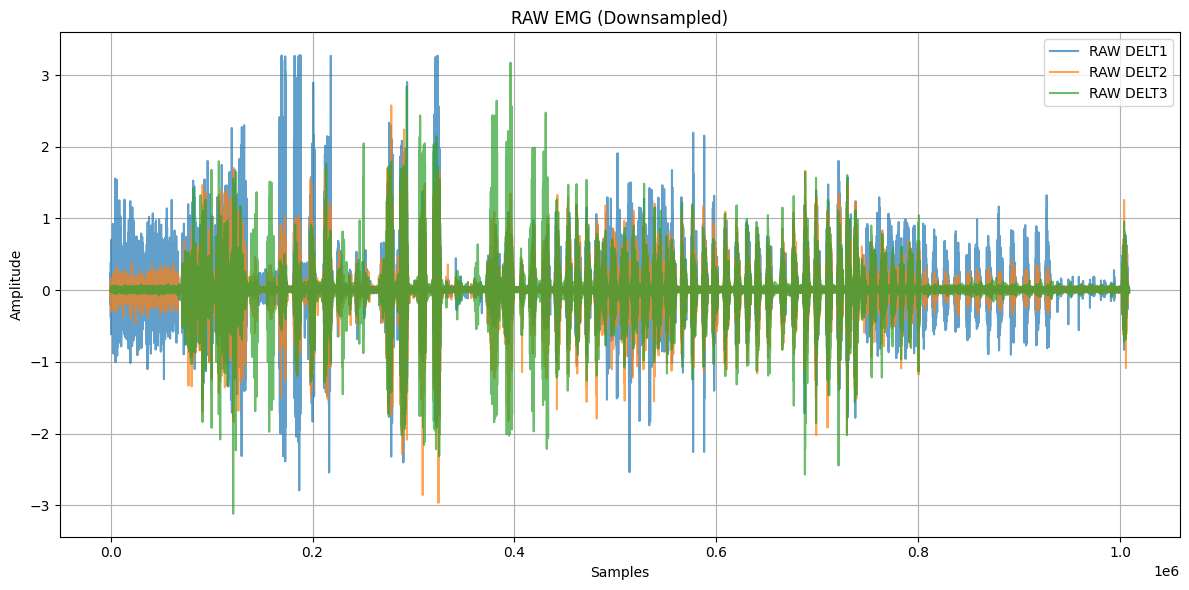

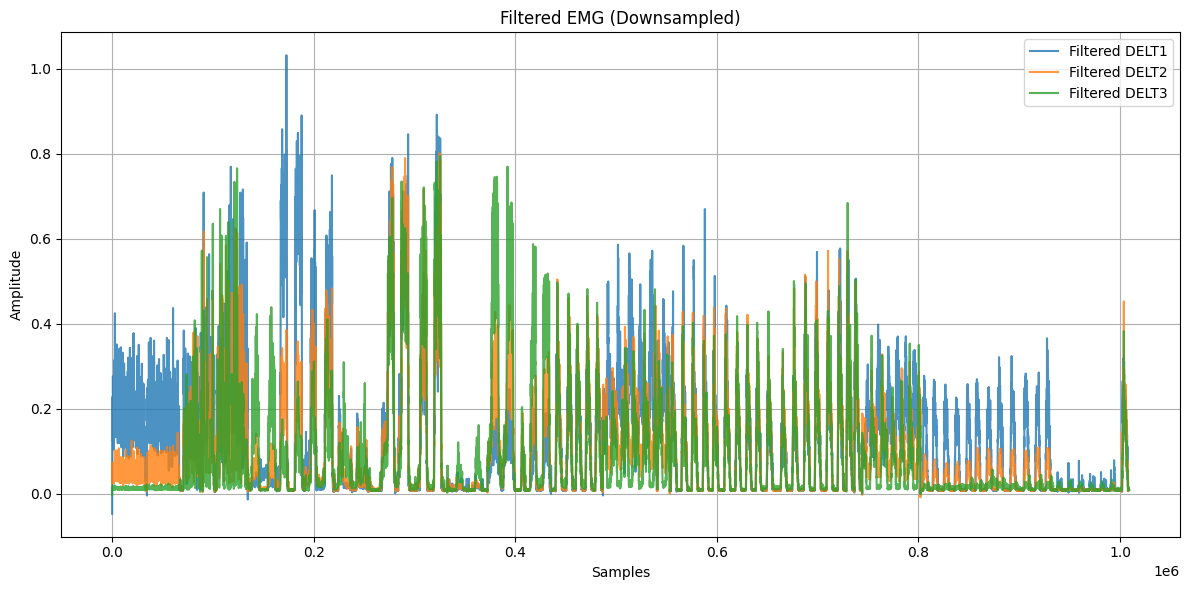

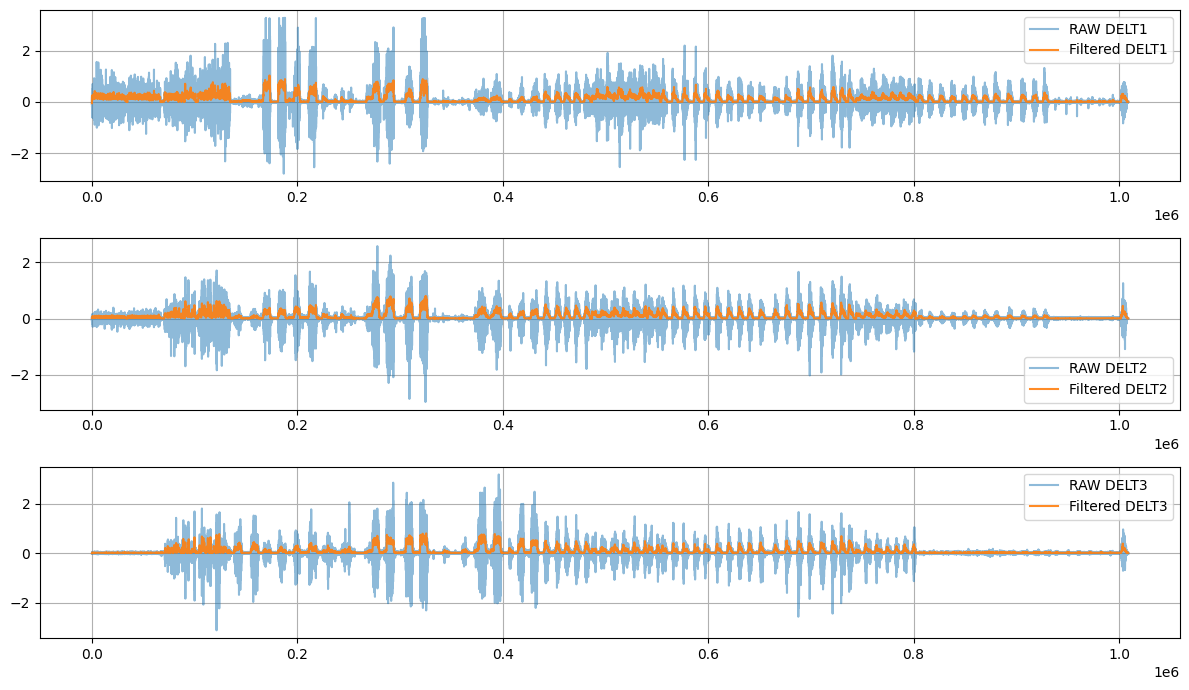

In [11]:
RAW_FILE = r"C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_RAW.csv"
FILTERED_FILE = r"C:\Users\Emadr\Desktop\dataset\H05\ALL_DELT_FILTERED.csv"

df_raw = pd.read_csv(RAW_FILE)
df_filt = pd.read_csv(FILTERED_FILE)

cols = ["DELT1", "DELT2", "DELT3"]

DOWNSAMPLE = 10     # take every 10th sample
df_raw = df_raw.iloc[::DOWNSAMPLE, :]
df_filt = df_filt.iloc[::DOWNSAMPLE, :]


# df_raw = df_raw.head(10000)
# df_filt = df_filt.head(10000)

# ===============================
# RAW plot
# ===============================
plt.figure(figsize=(12, 6))
for c in cols:
    plt.plot(df_raw[c], label=f"RAW {c}", alpha=0.7)
plt.title("RAW EMG (Downsampled)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Filtered plot
# ===============================
plt.figure(figsize=(12, 6))
for c in cols:
    plt.plot(df_filt[c], label=f"Filtered {c}", alpha=0.8)
plt.title("Filtered EMG (Downsampled)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Combined comparison
# ===============================
plt.figure(figsize=(12, 7))

for i, c in enumerate(cols):
    plt.subplot(3, 1, i + 1)
    plt.plot(df_raw[c], label=f"RAW {c}", alpha=0.5)
    plt.plot(df_filt[c], label=f"Filtered {c}", alpha=0.9)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Load CSV
df = pd.read_csv("ALL_DELT_FILTERED.csv")

rows = []

for idx, row in df.iterrows():
    # DELT1
    rows.append(["DELT1", row["DELT1"], 0])
    # DELT2
    rows.append(["DELT2", row["DELT2"], 1])
    # DELT3
    rows.append(["DELT3", row["DELT3"], 0])

# Create output dataframe
out = pd.DataFrame(rows, columns=["muscle", "value", "label"])

# Save
out.to_csv("output.csv", index=False)

print(out.head())


In [14]:
# ============================================================
# 1. Load dataset
# ============================================================
df = pd.read_csv("output.csv")
print("Dataset head:")
display(df.head())

# Only use value + label (no muscle as input to the model)
values = df["value"].values.astype(np.float32)
labels = df["label"].values.astype(np.float32)

print("Total raw samples:", len(values))


Dataset head:


,muscle,value,label
0,DELT1,0.004598,0
1,DELT2,0.006366,1
2,DELT3,0.003649,0
3,DELT1,0.004781,0
4,DELT2,0.006752,1


Total raw samples: 13574013


In [15]:
# ============================================================
# 2. Build sliding windows over EMG values
# ============================================================
window_size = 50   # try 50 first; you can try 20, 100, etc.
half = window_size // 2

X_list = []
y_list = []

# Centered windows, label = center sample's label
for i in range(half, len(values) - half):
    window = values[i-half : i+half]   # shape (window_size,)
    X_list.append(window)
    y_list.append(labels[i])

X = np.stack(X_list)                   # (N_windows, window_size)
y = np.array(y_list, dtype=np.float32) # (N_windows,)

print("X (windows) shape:", X.shape)
print("y shape:", y.shape)


X (windows) shape: (13573963, 50)
y shape: (13573963,)


In [16]:
# ============================================================
# 3. Train / Val / Test split (stratified)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train windows: {len(X_train)}")
print(f"Val windows:   {len(X_val)}")
print(f"Test windows:  {len(X_test)}")


Train windows: 9501774
Val windows:   2036094
Test windows:  2036095


In [24]:
# ============================================================
# 4. Class imbalance handling – compute pos_weight
# ============================================================
classes, counts = np.unique(y, return_counts=True)
print("Class counts (after windowing):", dict(zip(classes, counts)))

neg = counts[classes == 0][0]
pos = counts[classes == 1][0]
ratio = neg / pos
print("neg/pos ratio:", ratio)


Class counts (after windowing): {np.float32(0.0): np.int64(9049308), np.float32(1.0): np.int64(4524655)}
neg/pos ratio: 1.9999995579773486


In [23]:
# ============================================================
# 5. Dataset and DataLoaders
# ============================================================
class EMGWindowDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, window_size), y: (N,)
        # CNN expects (batch, channels, seq_len) -> we add channel dim later
        self.X = torch.from_numpy(X)      # float32
        self.y = torch.from_numpy(y)      # float32

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]                  # shape: (window_size,)
        x = x.unsqueeze(0)               # shape: (1, window_size) -> 1 channel
        y = self.y[idx]                  # scalar
        return x, y

train_dataset = EMGWindowDataset(X_train, y_train)
val_dataset   = EMGWindowDataset(X_val, y_val)
test_dataset  = EMGWindowDataset(X_test, y_test)

batch_size = 256  


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

In [21]:
# ============================================================
# 6. 1D CNN model definition
# ============================================================
class EMGCNN(nn.Module):
    def __init__(self, input_len, n_channels=1):
        super(EMGCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),          # L -> L/2
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2)           # L/2 -> L/4
        )
        # Global average pool to get fixed-size vector
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # (B, 32, 1)
        self.classifier = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 1)          # binary logit
        )

    def forward(self, x):
        # x: (B, 1, L)
        x = self.features(x)          # (B, 32, L')
        x = self.global_pool(x)       # (B, 32, 1)
        x = x.squeeze(-1)             # (B, 32)
        x = self.classifier(x)        # (B, 1)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = EMGCNN(input_len=window_size).to(device)

# Class-weighted loss
pos_weight = torch.tensor([ratio], device=device, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Using pos_weight:", pos_weight)

Using device: cuda
Using pos_weight: tensor([2.0000], device='cuda:0')


In [22]:
# ============================================================
# 6. multi CNN model definition
# ============================================================
class EMGCNN(nn.Module):
    def __init__(self, input_len, n_channels=1):
        super(EMGCNN, self).__init__()

        # Feature extractor: deeper CNN with BatchNorm + Dropout
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),          # L -> L/2

            # Block 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),          # L/2 -> L/4

            # Block 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)           # L/4 -> L/8
        )

        # Global average pooling -> fixed-size vector (B, 128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Classifier head with dropout
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)         # binary logit
        )

    def forward(self, x):
        # x: (B, 1, L)
        x = self.features(x)          # (B, 128, L')
        x = self.global_pool(x)       # (B, 128, 1)
        x = x.squeeze(-1)             # (B, 128)
        x = self.classifier(x)        # (B, 1)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = EMGCNN(input_len=window_size).to(device)

# Class-weighted loss
pos_weight = torch.tensor([ratio], device=device, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Using pos_weight:", pos_weight)

Using device: cuda
Using pos_weight: tensor([2.0000], device='cuda:0')


In [46]:
# ============================================================
# 7. Training / evaluation helpers with batch tracking
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="  Training", leave=False, ncols=80, disable=False)
    
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    all_probs = []
    
    pbar = tqdm(loader, desc="  Validating", leave=False, ncols=80, disable=False)

    with torch.no_grad():
        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    all_probs = np.vstack(all_probs).reshape(-1) if all_probs else np.array([])
    all_preds = np.vstack(all_preds).reshape(-1) if all_preds else np.array([])
    all_targets = np.vstack(all_targets).reshape(-1) if all_targets else np.array([])

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)

    return avg_loss, acc, all_targets, all_preds, all_probs


In [47]:
# ============================================================
# 8. Training loop with progress tracking and detailed metrics
# ============================================================
import time
from tqdm import tqdm

n_epochs = 20
best_val_loss = np.inf
best_state_dict = None
best_epoch = 0

print(f"\n{'='*100}")
print(f"Starting Training: {n_epochs} epochs")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"{'='*100}\n")

# Epoch-level progress bar
epoch_pbar = tqdm(range(1, n_epochs + 1), desc="Epochs", unit="epoch", ncols=100)

for epoch in epoch_pbar:
    epoch_start = time.time()
    
    # Train one epoch (with batch-level progress inside)
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate (with batch-level progress inside)
    val_loss, val_acc, y_true_val, y_pred_val, y_prob_val = evaluate(model, val_loader, criterion, device)
    
    epoch_time = time.time() - epoch_start
    
    # Check best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict().copy()
        best_epoch = epoch
        is_best = "✓ BEST"
    else:
        is_best = ""
    
    # Print detailed metrics for this epoch
    print(f"\nEpoch [{epoch:2d}/{n_epochs}] | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"{is_best}")
    
    # Update epoch progress with all metrics
    epoch_pbar.set_postfix({
        'Train Loss': f"{train_loss:.4f}",
        'Val Loss': f"{val_loss:.4f}",
        'Val Acc': f"{val_acc:.4f}",
        'Time': f"{epoch_time:.1f}s",
        'Best': is_best
    })

print(f"\n{'='*100}")
print(f"Training Complete!")
print(f"  • Best Epoch: {best_epoch}/{n_epochs}")
print(f"  • Best Val Loss: {best_val_loss:.6f}")
print(f"{'='*100}\n")

# Load best weights
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


Starting Training: 20 epochs
Train batches: 3712 | Val batches: 7954




Starting Training: 20 epochs
Train batches: 3712 | Val batches: 7954



Epochs:   5%| | 1/20 [00:54<17:20, 54.77s/epoch, Train Loss=0.5252, Val Loss=0.5216, Val Acc=0.7786,


Starting Training: 20 epochs
Train batches: 3712 | Val batches: 7954



Epochs:   5%| | 1/20 [00:54<17:20, 54.77s/epoch, Train Loss=0.5252, Val Loss=0.5216, Val Acc=0.7786,

...


Epoch [18/20] | Train Loss: 0.522866 | Val Loss: 0.518278 | Val Acc: 0.7899 | Time: 54.2s | ✓ BEST


Epochs:  95%|▉| 19/20 [17:27<00:54, 54.92s/epoch, Train Loss=0.5226, Val Loss=0.5202, Val Acc=0.7911


Epoch [19/20] | Train Loss: 0.522566 | Val Loss: 0.520191 | Val Acc: 0.7911 | Time: 55.0s | 


Epochs: 100%|█| 20/20 [18:24<00:00, 55.20s/epoch, Train Loss=0.5224, Val Loss=0.5239, Val Acc=0.7762


Epoch [20/20] | Train Loss: 0.522396 | Val Loss: 0.523932 | Val Acc: 0.7762 | Time: 56.3s | 

Training Complete!
  • Best Epoch: 18/20
  • Best Val Loss: 0.518278




                                      COMPREHENSIVE TEST SET EVALUATION                                       

 BASIC METRICS
--------------------------------------------------------------------------------------------------------------
Test Loss:              0.522554
Test Accuracy:          0.7768 (77.68%)
ROC-AUC Score:          0.8968
Average Precision:      0.8274

 CLASS-WISE PERFORMANCE
--------------------------------------------------------------------------------------------------------------

Class 0 (DELT1, DELT3):
  • Precision:  0.9093  (Out of predicted positives, 90.93% were correct)
  • Recall:     0.7389  (Model found 73.89% of actual Class 0 samples)
  • F1-Score:   0.8153
  • Specificity: 0.7389 (True Negative Rate)

Class 1 (DELT2 - Minority):
  • Precision:  0.6201  (Out of predicted positives, 62.01% were correct)
  • Recall:     0.8526  (Model found 85.26% of actual Class 1 samples)
  • F1-Score:   0.7180
  • Sensitivity: 0.8526 (True Positive Rate)

 CONFUSIO


                                      COMPREHENSIVE TEST SET EVALUATION                                       

 BASIC METRICS
--------------------------------------------------------------------------------------------------------------
Test Loss:              0.522554
Test Accuracy:          0.7768 (77.68%)
ROC-AUC Score:          0.8968
Average Precision:      0.8274

 CLASS-WISE PERFORMANCE
--------------------------------------------------------------------------------------------------------------

Class 0 (DELT1, DELT3):
  • Precision:  0.9093  (Out of predicted positives, 90.93% were correct)
  • Recall:     0.7389  (Model found 73.89% of actual Class 0 samples)
  • F1-Score:   0.8153
  • Specificity: 0.7389 (True Negative Rate)

Class 1 (DELT2 - Minority):
  • Precision:  0.6201  (Out of predicted positives, 62.01% were correct)
  • Recall:     0.8526  (Model found 85.26% of actual Class 1 samples)
  • F1-Score:   0.7180
  • Sensitivity: 0.8526 (True Positive Rate)

 CONFUSIO

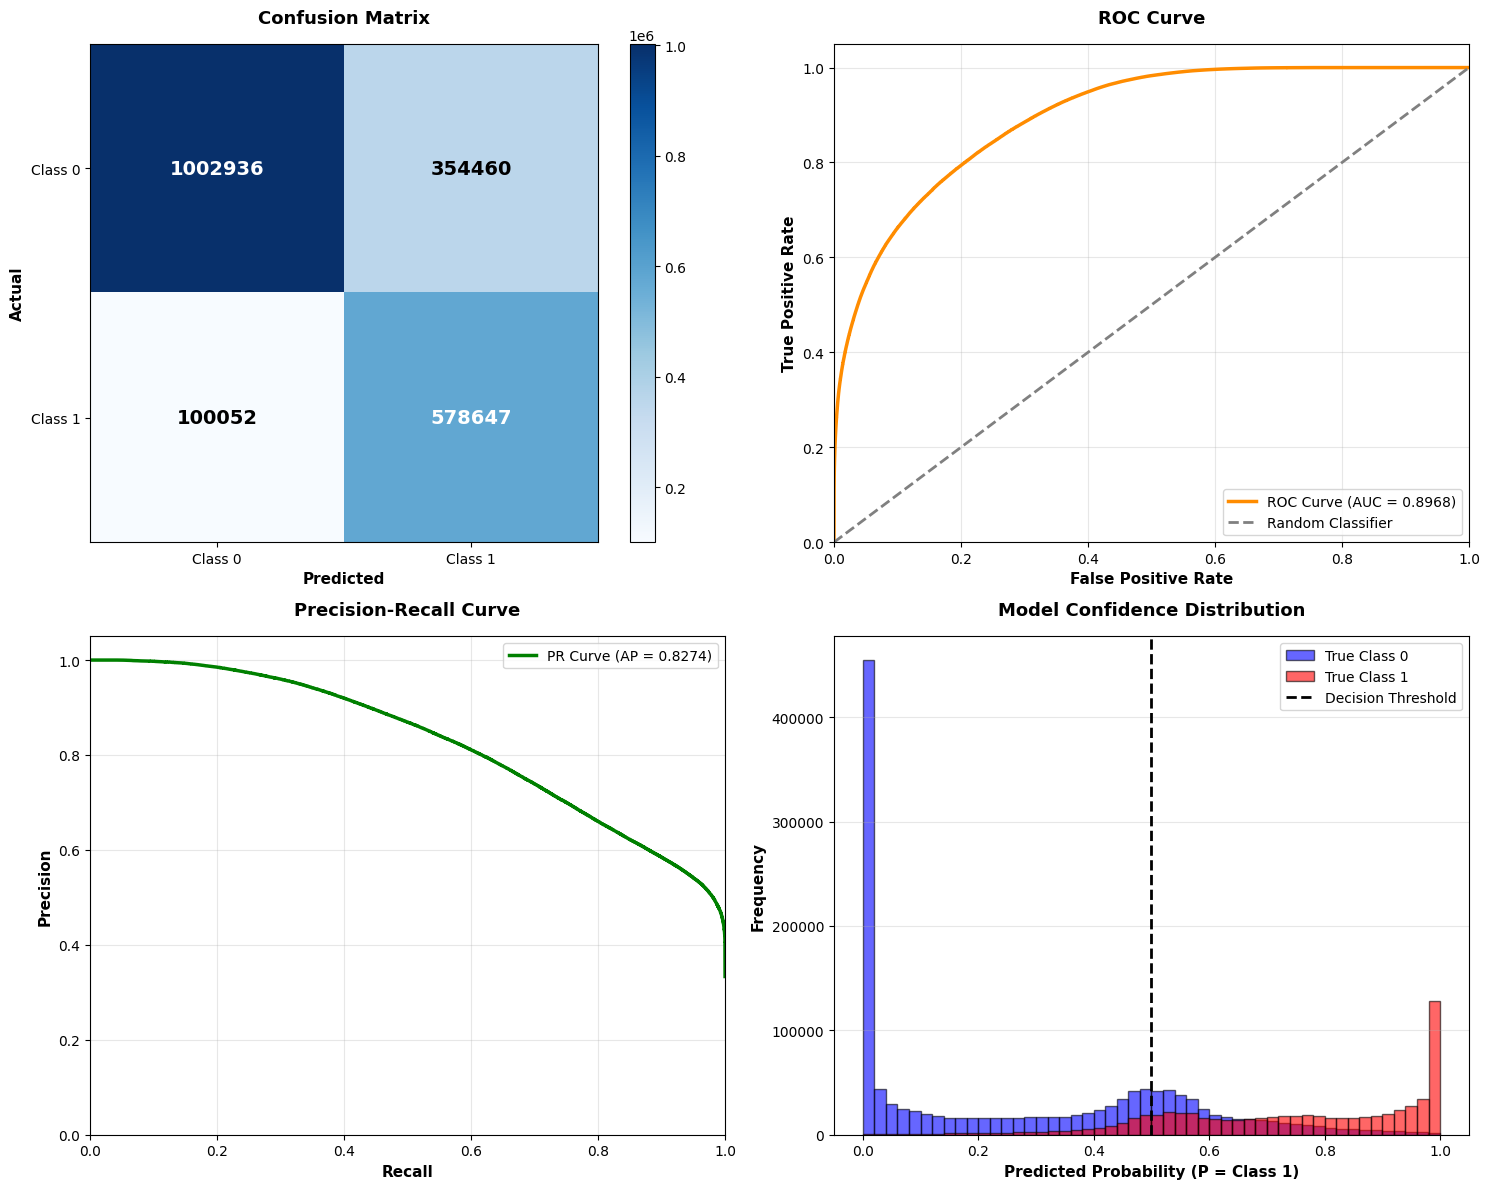

[✓] Comprehensive test evaluation plot saved as 'test_evaluation_comprehensive.png'

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.9093    0.7389    0.8153   1357396
     Class 1     0.6201    0.8526    0.7180    678699

    accuracy                         0.7768   2036095
   macro avg     0.7647    0.7957    0.7666   2036095
weighted avg     0.8129    0.7768    0.7828   2036095


 MODEL SUMMARY
Total Parameters:       52,353
Trainable Parameters:   52,353
Device:                 cuda
Model Type:             EMGCNN

[✓] Model saved as 'emg_deltoid2_cnn.pt'


In [48]:
# ============================================================
# 9. Final evaluation on TEST set (COMPREHENSIVE METRICS & CHARTS)
# ============================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Evaluate on test set with probabilities
test_loss, test_acc, y_true_test, y_pred_test, y_prob_test = evaluate(model, test_loader, criterion, device)

# Calculate detailed metrics
test_precision_0 = precision_score(y_true_test, y_pred_test, pos_label=0, zero_division=0)
test_precision_1 = precision_score(y_true_test, y_pred_test, pos_label=1, zero_division=0)
test_recall_0 = recall_score(y_true_test, y_pred_test, pos_label=0, zero_division=0)
test_recall_1 = recall_score(y_true_test, y_pred_test, pos_label=1, zero_division=0)
test_f1_0 = f1_score(y_true_test, y_pred_test, pos_label=0, zero_division=0)
test_f1_1 = f1_score(y_true_test, y_pred_test, pos_label=1, zero_division=0)

# AUC metrics
try:
    test_roc_auc = roc_auc_score(y_true_test, y_prob_test)
    test_ap = average_precision_score(y_true_test, y_prob_test)
except:
    test_roc_auc = 0.0
    test_ap = 0.0

# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

# Prediction distribution
unique, counts = np.unique(y_pred_test, return_counts=True)
pred_dist = {float(k): int(v) for k, v in zip(unique, counts)}
pred_0 = pred_dist.get(0.0, 0)
pred_1 = pred_dist.get(1.0, 0)

# True label distribution
true_0 = np.sum(y_true_test == 0)
true_1 = np.sum(y_true_test == 1)

# ===== PRINT COMPREHENSIVE METRICS =====
print("\n" + "=" * 110)
print("COMPREHENSIVE TEST SET EVALUATION".center(110))
print("=" * 110)

# Basic metrics
print("\n BASIC METRICS")
print("-" * 110)
print(f"Test Loss:              {test_loss:.6f}")
print(f"Test Accuracy:          {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"ROC-AUC Score:          {test_roc_auc:.4f}")
print(f"Average Precision:      {test_ap:.4f}")

# Per-class detailed metrics
print("\n CLASS-WISE PERFORMANCE")
print("-" * 110)
print(f"\nClass 0 (DELT1, DELT3):")
print(f"  • Precision:  {test_precision_0:.4f}  (Out of predicted positives, {test_precision_0*100:.2f}% were correct)")
print(f"  • Recall:     {test_recall_0:.4f}  (Model found {test_recall_0*100:.2f}% of actual Class 0 samples)")
print(f"  • F1-Score:   {test_f1_0:.4f}")
print(f"  • Specificity: {specificity:.4f} (True Negative Rate)")

print(f"\nClass 1 (DELT2 - Minority):")
print(f"  • Precision:  {test_precision_1:.4f}  (Out of predicted positives, {test_precision_1*100:.2f}% were correct)")
print(f"  • Recall:     {test_recall_1:.4f}  (Model found {test_recall_1*100:.2f}% of actual Class 1 samples)")
print(f"  • F1-Score:   {test_f1_1:.4f}")
print(f"  • Sensitivity: {sensitivity:.4f} (True Positive Rate)")

# Confusion matrix detailed
print("\n CONFUSION MATRIX")
print("-" * 110)
print(f"                  Predicted 0    Predicted 1    Total")
print(f"Actual 0:         {tn:>12}    {fp:>12}    {tn+fp:>8}")
print(f"Actual 1:         {fn:>12}    {tp:>12}    {fn+tp:>8}")
print(f"Total:            {tn+fn:>12}    {fp+tp:>12}    {len(y_true_test):>8}")

# Class distribution
print("\n CLASS DISTRIBUTION")
print("-" * 110)
print(f"True Labels:")
print(f"  • Class 0: {true_0:>8} samples ({true_0/(true_0+true_1)*100:>6.2f}%)")
print(f"  • Class 1: {true_1:>8} samples ({true_1/(true_0+true_1)*100:>6.2f}%)")
print(f"\nModel Predictions:")
print(f"  • Class 0: {pred_0:>8} samples ({pred_0/(pred_0+pred_1)*100:>6.2f}%)")
print(f"  • Class 1: {pred_1:>8} samples ({pred_1/(pred_0+pred_1)*100:>6.2f}%)")

print("\n" + "=" * 110 + "\n")

# ===== VISUALIZATIONS =====

# 1. Confusion Matrix Heatmap
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Confusion matrix
ax = axes[0, 0]
im = ax.imshow(cm, cmap="Blues", aspect='auto')
ax.set_xlabel("Predicted", fontsize=11, fontweight='bold')
ax.set_ylabel("Actual", fontsize=11, fontweight='bold')
ax.set_title("Confusion Matrix", fontsize=13, fontweight='bold', pad=15)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Class 0", "Class 1"])
ax.set_yticklabels(["Class 0", "Class 1"])
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=14, fontweight='bold')

# 2. ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=11, fontweight='bold')
ax.set_ylabel("True Positive Rate", fontsize=11, fontweight='bold')
ax.set_title("ROC Curve", fontsize=13, fontweight='bold', pad=15)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[1, 0]
prec, rec, _ = precision_recall_curve(y_true_test, y_prob_test)
ap = average_precision_score(y_true_test, y_prob_test)
ax.plot(rec, prec, color='green', lw=2.5, label=f'PR Curve (AP = {ap:.4f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall", fontsize=11, fontweight='bold')
ax.set_ylabel("Precision", fontsize=11, fontweight='bold')
ax.set_title("Precision-Recall Curve", fontsize=13, fontweight='bold', pad=15)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

# 4. Prediction probability distribution
ax = axes[1, 1]
ax.hist(y_prob_test[y_true_test == 0], bins=50, alpha=0.6, label="True Class 0", color='blue', edgecolor='black')
ax.hist(y_prob_test[y_true_test == 1], bins=50, alpha=0.6, label="True Class 1", color='red', edgecolor='black')
ax.axvline(0.5, linestyle='--', color='black', linewidth=2, label='Decision Threshold')
ax.set_xlabel("Predicted Probability (P = Class 1)", fontsize=11, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=11, fontweight='bold')
ax.set_title("Model Confidence Distribution", fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('test_evaluation_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print("[✓] Comprehensive test evaluation plot saved as 'test_evaluation_comprehensive.png'\n")

# Classification Report
print("DETAILED CLASSIFICATION REPORT")
print("=" * 110)
print(classification_report(y_true_test, y_pred_test, target_names=['Class 0', 'Class 1'], digits=4))
print("=" * 110)

# Model summary
print("\n MODEL SUMMARY")
print("=" * 110)
print(f"Total Parameters:       {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Device:                 {device}")
print(f"Model Type:             {model.__class__.__name__}")
print("=" * 110 + "\n")

# Optional: save model
torch.save(model.state_dict(), "emg_deltoid2_cnn.pt")
print("[✓] Model saved as 'emg_deltoid2_cnn.pt'")


In [ ]:
# ============================================================
# 8.5. Visualize Training Progress
# ============================================================

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Loss Curves (Top Left - spans 2 columns)
ax = fig.add_subplot(gs[0, :2])
ax.plot(training_history['epoch'], training_history['train_loss'], 'o-', linewidth=2.5, markersize=6, label='Train Loss', color='#FF6B6B')
ax.plot(training_history['epoch'], training_history['val_loss'], 's-', linewidth=2.5, markersize=6, label='Val Loss', color='#4ECDC4')
ax.axvline(best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax.set_title(' Loss Progression', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# 2. Best Epoch Indicator (Top Right)
ax = fig.add_subplot(gs[0, 2])
ax.axis('off')
info_text = f"""
🏆 BEST MODEL SUMMARY

Epoch: {best_epoch}/{n_epochs}
Val Loss: {best_val_loss:.6f}

Metrics at Best:
• Accuracy: {training_history['val_acc'][best_epoch-1]:.4f}
• ROC-AUC: {training_history['val_roc_auc'][best_epoch-1]:.4f}
• AP: {training_history['val_ap'][best_epoch-1]:.4f}
"""
ax.text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        family='monospace')

# 3. Accuracy Curve
ax = fig.add_subplot(gs[1, 0])
ax.plot(training_history['epoch'], training_history['val_acc'], 'o-', linewidth=2.5, markersize=6, color='#95E1D3')
ax.fill_between(training_history['epoch'], training_history['val_acc'], alpha=0.3, color='#95E1D3')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title(' Validation Accuracy', fontsize=12, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# 4. ROC-AUC and AP Curves
ax = fig.add_subplot(gs[1, 1])
ax.plot(training_history['epoch'], training_history['val_roc_auc'], 'o-', linewidth=2.5, markersize=6, label='ROC-AUC', color='#F38181')
ax.plot(training_history['epoch'], training_history['val_ap'], 's-', linewidth=2.5, markersize=6, label='Average Precision', color='#AA96DA')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('AUC Metrics', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# 5. F1 Score Comparison
ax = fig.add_subplot(gs[1, 2])
ax.plot(training_history['epoch'], training_history['val_f1_0'], 'o-', linewidth=2.5, markersize=6, label='Class 0 F1', color='#FCBAD3')
ax.plot(training_history['epoch'], training_history['val_f1_1'], 's-', linewidth=2.5, markersize=6, label='Class 1 F1', color='#A8D8EA')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax.set_title('F1-Score by Class', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# 6. Class 0 Metrics (Precision, Recall, F1)
ax = fig.add_subplot(gs[2, 0])
ax.plot(training_history['epoch'], training_history['val_precision_0'], 'o-', linewidth=2, markersize=5, label='Precision', color='#FF6B6B')
ax.plot(training_history['epoch'], training_history['val_recall_0'], 's-', linewidth=2, markersize=5, label='Recall', color='#4ECDC4')
ax.plot(training_history['epoch'], training_history['val_f1_0'], '^-', linewidth=2, markersize=5, label='F1', color='#FFE66D')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Class 0 Metrics', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# 7. Class 1 Metrics (Precision, Recall, F1)
ax = fig.add_subplot(gs[2, 1])
ax.plot(training_history['epoch'], training_history['val_precision_1'], 'o-', linewidth=2, markersize=5, label='Precision', color='#FF6B6B')
ax.plot(training_history['epoch'], training_history['val_recall_1'], 's-', linewidth=2, markersize=5, label='Recall', color='#4ECDC4')
ax.plot(training_history['epoch'], training_history['val_f1_1'], '^-', linewidth=2, markersize=5, label='F1', color='#FFE66D')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title(' Class 1 Metrics', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# 8. Class Balance (Predictions vs True)
ax = fig.add_subplot(gs[2, 2])
epochs = training_history['epoch']
x = np.arange(len(epochs))
width = 0.2

pred_0_pct = [training_history['pred_0_count'][i] / (training_history['pred_0_count'][i] + training_history['pred_1_count'][i]) * 100 for i in range(len(epochs))]
pred_1_pct = [100 - p for p in pred_0_pct]
true_0_pct = [training_history['true_0_count'][i] / (training_history['true_0_count'][i] + training_history['true_1_count'][i]) * 100 for i in range(len(epochs))]
true_1_pct = [100 - t for t in true_0_pct]

ax.plot(epochs, pred_0_pct, 'o-', linewidth=2, label='Pred Class 0 %', color='#FF6B6B')
ax.plot(epochs, true_0_pct, 's--', linewidth=2, label='True Class 0 %', color='#1A1A1A', alpha=0.7)
ax.axhline(y=true_0_pct[0], color='green', linestyle=':', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Class Balance Evolution', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('🎓 TRAINING PROGRESS VISUALIZATION', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[✓] Training progress visualization saved as 'training_progress.png'\n")

# Print training summary statistics
print("=" * 110)
print("TRAINING SUMMARY STATISTICS".center(110))
print("=" * 110)
print(f"\nInitial Metrics (Epoch 1):")
print(f"  • Loss:     {training_history['train_loss'][0]:.6f}")
print(f"  • Accuracy: {training_history['val_acc'][0]:.4f}")
print(f"  • ROC-AUC:  {training_history['val_roc_auc'][0]:.4f}")

print(f"\nBest Metrics (Epoch {best_epoch}):")
print(f"  • Loss:     {training_history['val_loss'][best_epoch-1]:.6f}")
print(f"  • Accuracy: {training_history['val_acc'][best_epoch-1]:.4f}")
print(f"  • ROC-AUC:  {training_history['val_roc_auc'][best_epoch-1]:.4f}")
print(f"  • AP:       {training_history['val_ap'][best_epoch-1]:.4f}")

print(f"\nFinal Metrics (Epoch {n_epochs}):")
print(f"  • Loss:     {training_history['val_loss'][-1]:.6f}")
print(f"  • Accuracy: {training_history['val_acc'][-1]:.4f}")
print(f"  • ROC-AUC:  {training_history['val_roc_auc'][-1]:.4f}")
print(f"  • AP:       {training_history['val_ap'][-1]:.4f}")Sol

print(f"\nImprovement from Epoch 1 to Best (Epoch {best_epoch}):")
loss_improvement = ((training_history['train_loss'][0] - training_history['val_loss'][best_epoch-1]) / training_history['train_loss'][0]) * 100
acc_improvement = ((training_history['val_acc'][best_epoch-1] - training_history['val_acc'][0]) / training_history['val_acc'][0]) * 100 if training_history['val_acc'][0] > 0 else 0
print(f"  • Loss:     {loss_improvement:.2f}% decrease")
print(f"  • Accuracy: {acc_improvement:.2f}% increase")

print("=" * 110 + "\n")
